# Notebook 05 — Rule-aware prioritization and candidate ranking

This notebook operationalizes the transition from **explainable and uncertainty-aware prediction** to **rule-aware candidate prioritization**.

It uses the outputs generated by:

- **Notebook 03**: trained models, ensemble probabilities, uncertainty estimates, and distance-aware splits.
- **Notebook 04**: SHAP-derived global importance, interpretable feature directions, and candidate descriptor rules.

The goal is not to introduce a new predictive model. Instead, this notebook shows how model confidence, predictive uncertainty, and interpretable rules can be combined into a transparent prioritization score for antimicrobial peptide candidates.

## Main outputs

- A machine-readable rulebook derived from SHAP and surrogate-tree evidence.
- Rule satisfaction matrices for each peptide.
- Rule-aware AMP prioritization scores.
- Exploitation and exploration candidate pools.
- Manuscript-ready tables and figures for the demonstrative case study.

In [1]:
# ============================================================
# 1. Imports and configuration
# ============================================================

from __future__ import annotations

import json
import math
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Input directories from previous notebooks
TRAINING_DIR = Path("../outputs_training")
EXPLAINABILITY_DIR = Path("../outputs_explainability")

TRAINING_METADATA_PATH = TRAINING_DIR / "training_metadata.json"
BEST_MODEL_SELECTION_PATH = TRAINING_DIR / "best_model_selection.json"
SPLIT_DATASET_PATH = TRAINING_DIR / "splits" / "amp_model_ready_with_distance_aware_split.csv"

RULE_EVIDENCE_PATH = EXPLAINABILITY_DIR / "rules" / "combined_explainability_rule_evidence.csv"
CANDIDATE_RULES_PATH = EXPLAINABILITY_DIR / "rules" / "candidate_interpretable_feature_rules_from_shap.csv"

# Output directory for this notebook
OUTPUT_DIR = Path("../outputs_rule_prioritization")
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
RULE_DIR = OUTPUT_DIR / "rules"
CANDIDATE_DIR = OUTPUT_DIR / "candidates"

for directory in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, RULE_DIR, CANDIDATE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Rule and score configuration
TOP_N_RULES = 12
MIN_RULE_WEIGHT = 1e-8

# Prioritization weights. These are intentionally simple and transparent.
WEIGHT_PROBABILITY = 0.55
WEIGHT_RULE_SCORE = 0.30
WEIGHT_CONFIDENCE = 0.15

# Candidate pool thresholds
HIGH_PROBABILITY_CUTOFF = 0.80
LOW_PROBABILITY_CUTOFF = 0.20
HIGH_RULE_SCORE_CUTOFF = 0.70
LOW_RULE_SCORE_CUTOFF = 0.30

TOP_N_EXPORT = 50

print(f"Output directory: {OUTPUT_DIR.resolve()}")

Output directory: /home/david/Desktop/umag_projects/demonstrative_AMR_peptide_discovery/outputs_rule_prioritization


## 2. Load training, prediction, and explainability artefacts

The notebook requires the exported artefacts from the previous stages. If one of these files is missing, rerun Notebook 03 and Notebook 04 before continuing.

In [2]:
# ============================================================
# 2. Load metadata, predictions, split dataset, and rule evidence
# ============================================================

required_paths = [
    TRAINING_METADATA_PATH,
    BEST_MODEL_SELECTION_PATH,
    SPLIT_DATASET_PATH,
    RULE_EVIDENCE_PATH,
    CANDIDATE_RULES_PATH,
]

missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Missing required artefacts. Please run Notebook 03 and Notebook 04 first."
        + "".join(missing_paths)
    )

with open(TRAINING_METADATA_PATH, "r") as f:
    training_metadata = json.load(f)

with open(BEST_MODEL_SELECTION_PATH, "r") as f:
    best_model_info = json.load(f)

SEQUENCE_COL = training_metadata.get("sequence_column", "sequence")
LABEL_COL = training_metadata.get("label_column", "label")
DESCRIPTOR_COLS = training_metadata["descriptor_columns"]
BEST_MODEL_NAME = best_model_info["best_model"]

prediction_path = Path(best_model_info["artifacts"]["prediction_path"])
if not prediction_path.exists():
    raise FileNotFoundError(
        f"Prediction file for selected model was not found: {prediction_path}"
    )

split_df = pd.read_csv(SPLIT_DATASET_PATH)
prediction_df = pd.read_csv(prediction_path)
rule_evidence_df = pd.read_csv(RULE_EVIDENCE_PATH)
candidate_rules_df = pd.read_csv(CANDIDATE_RULES_PATH)

print("Best model:", BEST_MODEL_NAME)
print("Prediction file:", prediction_path)
print("Split dataset:", split_df.shape)
print("Prediction dataset:", prediction_df.shape)
print("Rule evidence:", rule_evidence_df.shape)
print("Candidate rules:", candidate_rules_df.shape)

Best model: extra_trees
Prediction file: ../outputs_training/predictions/extra_trees_predictions_with_uncertainty.csv
Split dataset: (47175, 46)
Prediction dataset: (47175, 8)
Rule evidence: (41, 16)
Candidate rules: (20, 15)


In [3]:
# ============================================================
# 3. Build analysis table
# ============================================================

base_columns = [SEQUENCE_COL, LABEL_COL, "split", "distance_cluster"]
base_columns = [col for col in base_columns if col in split_df.columns]

analysis_df = prediction_df.copy()

missing_from_prediction = [col for col in base_columns + DESCRIPTOR_COLS if col not in analysis_df.columns]
if missing_from_prediction:
    merge_cols = [SEQUENCE_COL] + [col for col in missing_from_prediction if col in split_df.columns]
    analysis_df = analysis_df.merge(
        split_df[merge_cols].drop_duplicates(subset=SEQUENCE_COL),
        on=SEQUENCE_COL,
        how="left",
    )

if "probability_amp_ensemble" not in analysis_df.columns:
    candidate_prob_cols = [c for c in analysis_df.columns if "prob" in c.lower() and "amp" in c.lower()]
    if candidate_prob_cols:
        analysis_df["probability_amp_ensemble"] = analysis_df[candidate_prob_cols[0]]
    else:
        raise ValueError("Could not find AMP probability column in prediction file.")

if "uncertainty_std" not in analysis_df.columns:
    candidate_uncertainty_cols = [c for c in analysis_df.columns if "uncertainty" in c.lower() or "std" in c.lower()]
    if candidate_uncertainty_cols:
        analysis_df["uncertainty_std"] = analysis_df[candidate_uncertainty_cols[0]]
    else:
        raise ValueError("Could not find uncertainty column in prediction file.")

for col in DESCRIPTOR_COLS:
    if col in analysis_df.columns:
        analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

analysis_df["probability_amp_ensemble"] = pd.to_numeric(analysis_df["probability_amp_ensemble"], errors="coerce")
analysis_df["uncertainty_std"] = pd.to_numeric(analysis_df["uncertainty_std"], errors="coerce")

print(analysis_df.shape)
analysis_df[[SEQUENCE_COL, LABEL_COL, "split", "probability_amp_ensemble", "uncertainty_std"]].head()

(47175, 50)


,sequence,label,split,probability_amp_ensemble,uncertainty_std
0,RIQQIEQKIHHIEQRIQQIEQLLQLTVWGIKQLQARIL,1,train,0.9706,0.0882
1,LHYNWIDCCHYGVSDCC,0,train,0.0192,0.0576
2,WDEDGAKRIPVDVSE,0,train,0.0052,0.0156
3,MKIKTGARILALSALTTMMFSASALAK,0,train,0.0070,0.0210
4,MAPTVMMASSATAVAPFQGLKSTASLPVARRSSRSLGNVSNGGRIRCM,0,train,0.0004,0.0012


## 3. Build a machine-readable rulebook

The rulebook translates SHAP-derived feature directions and confident AMP-like descriptor ranges into explicit rules.

Examples:

- `charge >= threshold`
- `gravy <= threshold`
- `q25 <= entropy <= q75`

The final rule weight combines global SHAP importance and surrogate-tree importance when available.

In [4]:
# ============================================================
# 4. Helper functions for rule construction and scoring
# ============================================================

def minmax_normalize(values: pd.Series) -> pd.Series:
    values = pd.to_numeric(values, errors="coerce").fillna(0.0)
    vmin = float(values.min())
    vmax = float(values.max())
    if math.isclose(vmin, vmax):
        return pd.Series(np.ones(len(values)), index=values.index)
    return (values - vmin) / (vmax - vmin)


def build_rulebook(rule_evidence: pd.DataFrame, candidate_rules: pd.DataFrame, top_n_rules: int = 12) -> pd.DataFrame:
    """Build a machine-readable rulebook from SHAP and candidate-rule evidence."""
    evidence = rule_evidence.copy()

    if "mean_abs_shap" not in evidence.columns:
        raise ValueError("Rule evidence must include 'mean_abs_shap'.")

    if "surrogate_importance" not in evidence.columns:
        evidence["surrogate_importance"] = 0.0

    evidence = evidence.sort_values("mean_abs_shap", ascending=False).head(top_n_rules).copy()
    evidence = evidence.merge(
        candidate_rules[[
            "feature",
            "interpretable_direction",
            "selected_q25",
            "selected_median",
            "selected_q75",
            "background_median",
            "candidate_rule_from_confident_amp_like_region",
        ]].drop_duplicates(subset="feature"),
        on="feature",
        how="left",
        suffixes=("", "_candidate"),
    )

    if "interpretable_direction_candidate" in evidence.columns:
        evidence["interpretable_direction"] = evidence["interpretable_direction_candidate"].fillna(evidence["interpretable_direction"])

    evidence["mean_abs_shap_norm"] = minmax_normalize(evidence["mean_abs_shap"])
    evidence["surrogate_importance_norm"] = minmax_normalize(evidence["surrogate_importance"])

    evidence["rule_weight"] = 0.75 * evidence["mean_abs_shap_norm"] + 0.25 * evidence["surrogate_importance_norm"]
    evidence["rule_weight"] = evidence["rule_weight"].clip(lower=MIN_RULE_WEIGHT)
    evidence["rule_weight"] = evidence["rule_weight"] / evidence["rule_weight"].sum()

    rule_rows = []
    for _, row in evidence.iterrows():
        feature = row["feature"]
        direction = row.get("interpretable_direction", "non_monotonic_or_weak_direction")
        q25 = float(row.get("selected_q25", np.nan))
        q75 = float(row.get("selected_q75", np.nan))
        median = float(row.get("selected_median", np.nan))

        if pd.isna(q25) or pd.isna(q75):
            continue

        if direction == "higher_values_support_AMP_prediction":
            operator = ">="
            lower_bound = q25
            upper_bound = np.nan
            rule_text = f"{feature} >= {q25:.4g}"
        elif direction == "lower_values_support_AMP_prediction":
            operator = "<="
            lower_bound = np.nan
            upper_bound = q75
            rule_text = f"{feature} <= {q75:.4g}"
        else:
            operator = "between"
            lower_bound = q25
            upper_bound = q75
            rule_text = f"{q25:.4g} <= {feature} <= {q75:.4g}"

        rule_rows.append({
            "feature": feature,
            "rule_text": rule_text,
            "operator": operator,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "selected_median": median,
            "interpretable_direction": direction,
            "mean_abs_shap": float(row.get("mean_abs_shap", np.nan)),
            "surrogate_importance": float(row.get("surrogate_importance", 0.0)),
            "rule_weight": float(row["rule_weight"]),
        })

    return pd.DataFrame(rule_rows)


def evaluate_rule(values: pd.Series, operator: str, lower: float, upper: float) -> pd.Series:
    """Evaluate a rule and return a binary satisfaction vector."""
    values = pd.to_numeric(values, errors="coerce")

    if operator == ">=":
        return values.ge(lower).fillna(False).astype(int)
    if operator == "<=":
        return values.le(upper).fillna(False).astype(int)
    if operator == "between":
        return (values.ge(lower) & values.le(upper)).fillna(False).astype(int)

    raise ValueError(f"Unsupported operator: {operator}")


def evaluate_rule_soft(values: pd.Series, operator: str, lower: float, upper: float) -> pd.Series:
    """Evaluate a rule using a soft score in [0, 1]."""
    x = pd.to_numeric(values, errors="coerce")
    finite = np.isfinite(x)
    if finite.sum() == 0:
        return pd.Series(np.zeros(len(x)), index=x.index)

    xmin = float(np.nanpercentile(x[finite], 1))
    xmax = float(np.nanpercentile(x[finite], 99))
    span = max(xmax - xmin, 1e-8)

    if operator == ">=":
        score = (x - lower) / span + 0.5
    elif operator == "<=":
        score = (upper - x) / span + 0.5
    elif operator == "between":
        center = (lower + upper) / 2.0
        half_width = max((upper - lower) / 2.0, 1e-8)
        score = 1.0 - (np.abs(x - center) / (2.0 * half_width))
    else:
        raise ValueError(f"Unsupported operator: {operator}")

    return score.clip(0.0, 1.0).fillna(0.0)

In [5]:
# ============================================================
# 5. Build and export rulebook
# ============================================================

rulebook_df = build_rulebook(
    rule_evidence=rule_evidence_df,
    candidate_rules=candidate_rules_df,
    top_n_rules=TOP_N_RULES,
)

if rulebook_df.empty:
    raise ValueError("No rules could be generated. Check Notebook 04 outputs.")

rulebook_path = RULE_DIR / "amp_rulebook_from_shap_and_surrogate.csv"
rulebook_df.to_csv(rulebook_path, index=False)

print("Saved:", rulebook_path)
rulebook_df

Saved: ../outputs_rule_prioritization/rules/amp_rulebook_from_shap_and_surrogate.csv


,feature,rule_text,operator,lower_bound,upper_bound,selected_median,interpretable_direction,mean_abs_shap,surrogate_importance,rule_weight
0,AAC_K,AAC_K >= 0.08333,>=,0.083333,NaN,0.222222,higher_values_support_AMP_prediction,0.044008,0.170453,2.656973e-01
1,AAC_M,AAC_M <= 0,<=,NaN,0.000000,0.000000,lower_values_support_AMP_prediction,0.035435,0.133516,1.894004e-01
2,isoelectric_point_approx,isoelectric_point_approx >= 10.84,>=,10.840000,NaN,11.210000,higher_values_support_AMP_prediction,0.032766,0.000000,1.447430e-01
3,positive_fraction,positive_fraction >= 0.2857,>=,0.285714,NaN,0.375000,higher_values_support_AMP_prediction,0.030998,0.460082,2.091449e-01
4,small_fraction,small_fraction <= 0.3333,<=,NaN,0.333333,0.166667,lower_values_support_AMP_prediction,0.020585,0.005720,4.631380e-02
5,polar_fraction,polar_fraction <= 0.1,<=,NaN,0.100000,0.000000,lower_values_support_AMP_prediction,0.018879,0.000000,3.141087e-02
6,unique_residue_fraction,unique_residue_fraction <= 0.5385,<=,NaN,0.538462,0.416667,lower_values_support_AMP_prediction,0.018787,0.000000,3.066264e-02
7,AAC_S,AAC_S <= 0,<=,NaN,0.000000,0.000000,lower_values_support_AMP_prediction,0.018572,0.000000,2.890751e-02
8,net_charge_pH_7_4,net_charge_pH_7_4 >= 2.994,>=,2.994097,NaN,3.994874,higher_values_support_AMP_prediction,0.017311,0.096703,3.518422e-02
9,charged_fraction,charged_fraction >= 0.3,>=,0.300000,NaN,0.384615,higher_values_support_AMP_prediction,0.016490,0.000000,1.191265e-02


## 4. Compute rule satisfaction and rule-aware scores

For each peptide, the notebook calculates:

- `binary_rule_score`: fraction of rules satisfied.
- `weighted_rule_score`: weighted fraction of satisfied rules.
- `soft_rule_score`: continuous score that reduces sharp threshold effects.
- `uncertainty_risk`: normalized uncertainty.
- `confidence_score`: inverse uncertainty.
- `rule_aware_priority_score`: final prioritization score.

In [6]:
# ============================================================
# 6. Evaluate rules for each peptide
# ============================================================

rule_binary_cols = []
rule_soft_cols = []

for rule_id, row in rulebook_df.reset_index(drop=True).iterrows():
    feature = row["feature"]
    if feature not in analysis_df.columns:
        print(f"Skipping rule because feature is missing from analysis table: {feature}")
        continue

    binary_col = f"rule_{rule_id + 1:02d}__{feature}__binary"
    soft_col = f"rule_{rule_id + 1:02d}__{feature}__soft"

    analysis_df[binary_col] = evaluate_rule(
        analysis_df[feature],
        operator=row["operator"],
        lower=row["lower_bound"],
        upper=row["upper_bound"],
    )
    analysis_df[soft_col] = evaluate_rule_soft(
        analysis_df[feature],
        operator=row["operator"],
        lower=row["lower_bound"],
        upper=row["upper_bound"],
    )

    rule_binary_cols.append(binary_col)
    rule_soft_cols.append(soft_col)

if not rule_binary_cols:
    raise ValueError("No rules could be evaluated because rule features were not found.")

rule_weights = rulebook_df.iloc[:len(rule_binary_cols)]["rule_weight"].to_numpy(dtype=float)
rule_weights = rule_weights / rule_weights.sum()

analysis_df["n_rules_satisfied"] = analysis_df[rule_binary_cols].sum(axis=1)
analysis_df["n_rules_total"] = len(rule_binary_cols)
analysis_df["binary_rule_score"] = analysis_df["n_rules_satisfied"] / analysis_df["n_rules_total"]
analysis_df["weighted_rule_score"] = analysis_df[rule_binary_cols].to_numpy(dtype=float).dot(rule_weights)
analysis_df["soft_rule_score"] = analysis_df[rule_soft_cols].to_numpy(dtype=float).dot(rule_weights)

analysis_df[[SEQUENCE_COL, "probability_amp_ensemble", "uncertainty_std", "binary_rule_score", "weighted_rule_score", "soft_rule_score"]].head()

,sequence,probability_amp_ensemble,uncertainty_std,binary_rule_score,weighted_rule_score,soft_rule_score
0,RIQQIEQKIHHIEQRIQQIEQLLQLTVWGIKQLQARIL,0.9706,0.0882,0.416667,0.301907,0.455761
1,LHYNWIDCCHYGVSDCC,0.0192,0.0576,0.166667,0.196023,0.273568
2,WDEDGAKRIPVDVSE,0.0052,0.0156,0.416667,0.239347,0.332591
3,MKIKTGARILALSALTTMMFSASALAK,0.0070,0.0210,0.500000,0.482910,0.371794
4,MAPTVMMASSATAVAPFQGLKSTASLPVARRSSRSLGNVSNGGRIRCM,0.0004,0.0012,0.416667,0.217213,0.302574


In [7]:
# ============================================================
# 7. Build final rule-aware prioritization score
# ============================================================

uncertainty = analysis_df["uncertainty_std"].astype(float)
uncertainty_scale = float(np.nanpercentile(uncertainty, 95))
if uncertainty_scale <= 0 or np.isnan(uncertainty_scale):
    uncertainty_scale = float(uncertainty.max()) if uncertainty.max() > 0 else 1.0

analysis_df["uncertainty_risk"] = (uncertainty / uncertainty_scale).clip(0.0, 1.0)
analysis_df["confidence_score"] = 1.0 - analysis_df["uncertainty_risk"]

analysis_df["rule_aware_priority_score"] = (
    WEIGHT_PROBABILITY * analysis_df["probability_amp_ensemble"]
    + WEIGHT_RULE_SCORE * analysis_df["soft_rule_score"]
    + WEIGHT_CONFIDENCE * analysis_df["confidence_score"]
)

analysis_df["rule_aware_priority_score"] = analysis_df["rule_aware_priority_score"].clip(0.0, 1.0)
analysis_df["priority_rank"] = analysis_df["rule_aware_priority_score"].rank(method="first", ascending=False).astype(int)

ranked_df = analysis_df.sort_values("rule_aware_priority_score", ascending=False).reset_index(drop=True)

score_summary = ranked_df[[
    "probability_amp_ensemble",
    "uncertainty_std",
    "uncertainty_risk",
    "confidence_score",
    "binary_rule_score",
    "weighted_rule_score",
    "soft_rule_score",
    "rule_aware_priority_score",
]].describe().T

score_summary

,count,mean,std,min,25%,50%,75%,max
probability_amp_ensemble,47175.0,0.350601,0.408526,0.000000,0.017800,0.085200,0.921600,1.000000
uncertainty_std,47175.0,0.060615,0.061589,0.000000,0.017400,0.035400,0.084600,0.297990
uncertainty_risk,47175.0,0.291248,0.282367,0.000000,0.085799,0.174556,0.417160,1.000000
confidence_score,47175.0,0.708752,0.282367,0.000000,0.582840,0.825444,0.914201,1.000000
binary_rule_score,47175.0,0.391668,0.226082,0.083333,0.250000,0.333333,0.500000,1.000000
weighted_rule_score,47175.0,0.350921,0.265385,0.006623,0.196023,0.255593,0.494823,1.000000
soft_rule_score,47175.0,0.380304,0.134548,0.109644,0.279172,0.359303,0.448985,0.817778
rule_aware_priority_score,47175.0,0.413235,0.239868,0.089515,0.219953,0.281506,0.627645,0.943574


## 5. Define candidate pools

The ranking is split into transparent candidate groups:

- **Exploitation candidates**: high predicted AMP probability, low uncertainty, and high rule support.
- **Exploration candidates**: promising but uncertain candidates that may be informative for experimental testing.
- **Low-priority candidates**: low predicted probability, low rule support, or both.

These groups are intended to support decision-making, not to replace experimental validation.

In [8]:
# ============================================================
# 8. Candidate pool assignment
# ============================================================

uncertainty_low_cutoff = float(analysis_df["uncertainty_std"].quantile(0.25))
uncertainty_high_cutoff = float(analysis_df["uncertainty_std"].quantile(0.75))

prob = analysis_df["probability_amp_ensemble"]
unc = analysis_df["uncertainty_std"]
rule = analysis_df["soft_rule_score"]

analysis_df["candidate_pool"] = "standard_priority"

analysis_df.loc[
    prob.ge(HIGH_PROBABILITY_CUTOFF)
    & unc.le(uncertainty_low_cutoff)
    & rule.ge(HIGH_RULE_SCORE_CUTOFF),
    "candidate_pool",
] = "exploitation_high_confidence_rule_supported"

analysis_df.loc[
    prob.ge(0.60)
    & unc.ge(uncertainty_high_cutoff)
    & rule.ge(0.50),
    "candidate_pool",
] = "exploration_promising_but_uncertain"

analysis_df.loc[
    prob.le(LOW_PROBABILITY_CUTOFF)
    & rule.le(LOW_RULE_SCORE_CUTOFF),
    "candidate_pool",
] = "low_priority"

ranked_df = analysis_df.sort_values("rule_aware_priority_score", ascending=False).reset_index(drop=True)
ranked_df["priority_rank"] = np.arange(1, len(ranked_df) + 1)

pool_summary = (
    ranked_df
    .groupby("candidate_pool")
    .agg(
        n=(SEQUENCE_COL, "count"),
        mean_probability=("probability_amp_ensemble", "mean"),
        mean_uncertainty=("uncertainty_std", "mean"),
        mean_rule_score=("soft_rule_score", "mean"),
        mean_priority_score=("rule_aware_priority_score", "mean"),
    )
    .sort_values("mean_priority_score", ascending=False)
)

pool_summary

,n,mean_probability,mean_uncertainty,mean_rule_score,mean_priority_score
candidate_pool,,,,,
exploitation_high_confidence_rule_supported,889,0.990760,0.004482,0.742233,0.914273
exploration_promising_but_uncertain,1011,0.944813,0.133014,0.574600,0.745130
standard_priority,33981,0.419994,0.067160,0.410512,0.456021
low_priority,11294,0.038234,0.038858,0.243534,0.215352


In [9]:
# ============================================================
# 9. Export ranked candidates and pool-specific files
# ============================================================

priority_columns = [
    "priority_rank",
    SEQUENCE_COL,
    LABEL_COL,
    "split",
    "candidate_pool",
    "probability_amp_ensemble",
    "uncertainty_std",
    "uncertainty_risk",
    "confidence_score",
    "n_rules_satisfied",
    "n_rules_total",
    "binary_rule_score",
    "weighted_rule_score",
    "soft_rule_score",
    "rule_aware_priority_score",
]
priority_columns = [col for col in priority_columns if col in ranked_df.columns]

descriptor_columns_present = [col for col in DESCRIPTOR_COLS if col in ranked_df.columns]
rule_columns_present = rule_binary_cols + rule_soft_cols

full_ranked_path = TABLE_DIR / "all_candidates_rule_aware_ranked.csv"
ranked_df[priority_columns + descriptor_columns_present + rule_columns_present].to_csv(full_ranked_path, index=False)

pool_summary_path = TABLE_DIR / "candidate_pool_summary.csv"
pool_summary.to_csv(pool_summary_path)

top_candidates_path = CANDIDATE_DIR / f"top_{TOP_N_EXPORT}_rule_aware_candidates.csv"
ranked_df.head(TOP_N_EXPORT)[priority_columns + descriptor_columns_present].to_csv(top_candidates_path, index=False)

exploitation_path = CANDIDATE_DIR / "exploitation_high_confidence_rule_supported_candidates.csv"
ranked_df[ranked_df["candidate_pool"].eq("exploitation_high_confidence_rule_supported")][priority_columns + descriptor_columns_present].to_csv(exploitation_path, index=False)

exploration_path = CANDIDATE_DIR / "exploration_promising_but_uncertain_candidates.csv"
ranked_df[ranked_df["candidate_pool"].eq("exploration_promising_but_uncertain")][priority_columns + descriptor_columns_present].to_csv(exploration_path, index=False)

low_priority_path = CANDIDATE_DIR / "low_priority_candidates.csv"
ranked_df[ranked_df["candidate_pool"].eq("low_priority")][priority_columns + descriptor_columns_present].to_csv(low_priority_path, index=False)

print("Saved:", full_ranked_path)
print("Saved:", pool_summary_path)
print("Saved:", top_candidates_path)
print("Saved:", exploitation_path)
print("Saved:", exploration_path)
print("Saved:", low_priority_path)

ranked_df[priority_columns].head(20)

Saved: ../outputs_rule_prioritization/tables/all_candidates_rule_aware_ranked.csv
Saved: ../outputs_rule_prioritization/tables/candidate_pool_summary.csv
Saved: ../outputs_rule_prioritization/candidates/top_50_rule_aware_candidates.csv
Saved: ../outputs_rule_prioritization/candidates/exploitation_high_confidence_rule_supported_candidates.csv
Saved: ../outputs_rule_prioritization/candidates/exploration_promising_but_uncertain_candidates.csv
Saved: ../outputs_rule_prioritization/candidates/low_priority_candidates.csv


,priority_rank,sequence,label,split,candidate_pool,probability_amp_ensemble,uncertainty_std,uncertainty_risk,confidence_score,n_rules_satisfied,n_rules_total,binary_rule_score,weighted_rule_score,soft_rule_score,rule_aware_priority_score
0,1,KFKKFKKFKKFKKFKKFKKFK,1,train,exploitation_high_confidence_rule_supported,1.000000,0.000000,0.000000,1.000000,12,12,1.0,1.0,0.811913,0.943574
1,2,KFKKFKKFKKFKKFKKFKKFKKFKKFK,1,train,exploitation_high_confidence_rule_supported,0.999600,0.001200,0.005917,0.994083,12,12,1.0,1.0,0.813657,0.942989
2,3,KFKKFKKFKKFKKFKKFKKFKKFK,1,train,exploitation_high_confidence_rule_supported,0.999600,0.001200,0.005917,0.994083,12,12,1.0,1.0,0.812864,0.942752
3,4,KKKKKKKKKKK,1,train,exploitation_high_confidence_rule_supported,1.000000,0.000000,0.000000,1.000000,12,12,1.0,1.0,0.809155,0.942746
4,5,KFKKFKKFKKFKKFKKFK,1,train,exploitation_high_confidence_rule_supported,0.999800,0.000600,0.002959,0.997041,12,12,1.0,1.0,0.810803,0.942687
5,6,KKKKKKKKKKKK,1,train,exploitation_high_confidence_rule_supported,0.999800,0.000600,0.002959,0.997041,12,12,1.0,1.0,0.810803,0.942687
6,7,KKKKKKKKKKKKK,1,validation,exploitation_high_confidence_rule_supported,0.997600,0.002154,0.010622,0.989378,12,12,1.0,1.0,0.811437,0.940518
7,8,KRKKLLKRLL,1,train,exploitation_high_confidence_rule_supported,1.000000,0.000000,0.000000,1.000000,12,12,1.0,1.0,0.799573,0.939872
8,9,KKKKLLLLRR,1,train,exploitation_high_confidence_rule_supported,1.000000,0.000000,0.000000,1.000000,12,12,1.0,1.0,0.799573,0.939872
9,10,RKKKIKIIKKII,1,train,exploitation_high_confidence_rule_supported,0.999800,0.000600,0.002959,0.997041,12,12,1.0,1.0,0.800600,0.939626


## 6. Rule diagnostics

The following tables summarize which rules are most frequently satisfied and how rule satisfaction relates to model probability and uncertainty.

In [10]:
# ============================================================
# 10. Rule-level diagnostics
# ============================================================

rule_diagnostic_rows = []

for i, binary_col in enumerate(rule_binary_cols):
    feature = rulebook_df.iloc[i]["feature"]
    satisfied = analysis_df[binary_col].astype(bool)

    rule_diagnostic_rows.append({
        "rule_id": i + 1,
        "feature": feature,
        "rule_text": rulebook_df.iloc[i]["rule_text"],
        "rule_weight": float(rulebook_df.iloc[i]["rule_weight"]),
        "n_satisfied": int(satisfied.sum()),
        "fraction_satisfied": float(satisfied.mean()),
        "mean_probability_when_satisfied": float(analysis_df.loc[satisfied, "probability_amp_ensemble"].mean()),
        "mean_probability_when_not_satisfied": float(analysis_df.loc[~satisfied, "probability_amp_ensemble"].mean()),
        "mean_uncertainty_when_satisfied": float(analysis_df.loc[satisfied, "uncertainty_std"].mean()),
        "mean_uncertainty_when_not_satisfied": float(analysis_df.loc[~satisfied, "uncertainty_std"].mean()),
        "mean_priority_score_when_satisfied": float(analysis_df.loc[satisfied, "rule_aware_priority_score"].mean()),
        "mean_priority_score_when_not_satisfied": float(analysis_df.loc[~satisfied, "rule_aware_priority_score"].mean()),
    })

rule_diagnostics_df = pd.DataFrame(rule_diagnostic_rows)
rule_diagnostics_path = TABLE_DIR / "rule_level_diagnostics.csv"
rule_diagnostics_df.to_csv(rule_diagnostics_path, index=False)

print("Saved:", rule_diagnostics_path)
rule_diagnostics_df

Saved: ../outputs_rule_prioritization/tables/rule_level_diagnostics.csv


,rule_id,feature,rule_text,rule_weight,n_satisfied,fraction_satisfied,mean_probability_when_satisfied,mean_probability_when_not_satisfied,mean_uncertainty_when_satisfied,mean_uncertainty_when_not_satisfied,mean_priority_score_when_satisfied,mean_priority_score_when_not_satisfied
0,1,AAC_K,AAC_K >= 0.08333,2.656973e-01,16073,0.340710,0.557445,0.243708,0.066570,0.057537,0.558563,0.338131
1,2,AAC_M,AAC_M <= 0,1.894004e-01,28866,0.611892,0.439677,0.210165,0.064415,0.054624,0.469578,0.324404
2,3,isoelectric_point_approx,isoelectric_point_approx >= 10.84,1.447430e-01,14651,0.310567,0.460783,0.300968,0.044881,0.067702,0.517461,0.366284
3,4,positive_fraction,positive_fraction >= 0.2857,2.091449e-01,8122,0.172167,0.726923,0.272336,0.054714,0.061842,0.688646,0.355956
4,5,small_fraction,small_fraction <= 0.3333,4.631380e-02,9959,0.211108,0.609272,0.281381,0.054227,0.062324,0.599611,0.363360
5,6,polar_fraction,polar_fraction <= 0.1,3.141087e-02,9206,0.195146,0.603258,0.289342,0.046957,0.063926,0.597047,0.368668
6,7,unique_residue_fraction,unique_residue_fraction <= 0.5385,3.066264e-02,24869,0.527165,0.406311,0.288491,0.056298,0.065427,0.454864,0.366822
7,8,AAC_S,AAC_S <= 0,2.890751e-02,17934,0.380159,0.459206,0.283992,0.058416,0.061963,0.489615,0.366390
8,9,net_charge_pH_7_4,net_charge_pH_7_4 >= 2.994,3.518422e-02,13545,0.287122,0.522398,0.281408,0.048574,0.065464,0.553966,0.356553
9,10,charged_fraction,charged_fraction >= 0.3,1.191265e-02,14877,0.315358,0.513133,0.275737,0.062075,0.059942,0.533112,0.358017


In [11]:
# ============================================================
# 11. Manuscript-ready summary tables
# ============================================================

manuscript_rulebook = rulebook_df[[
    "feature",
    "rule_text",
    "interpretable_direction",
    "mean_abs_shap",
    "surrogate_importance",
    "rule_weight",
]].copy()

manuscript_rulebook_path = TABLE_DIR / "manuscript_ready_rulebook.csv"
manuscript_rulebook.to_csv(manuscript_rulebook_path, index=False)

manuscript_top_candidates = ranked_df.head(20)[priority_columns].copy()
manuscript_top_candidates_path = TABLE_DIR / "manuscript_ready_top_20_candidates.csv"
manuscript_top_candidates.to_csv(manuscript_top_candidates_path, index=False)

print("Saved:", manuscript_rulebook_path)
print("Saved:", manuscript_top_candidates_path)

display(manuscript_rulebook)
display(manuscript_top_candidates)

Saved: ../outputs_rule_prioritization/tables/manuscript_ready_rulebook.csv
Saved: ../outputs_rule_prioritization/tables/manuscript_ready_top_20_candidates.csv


,feature,rule_text,interpretable_direction,mean_abs_shap,surrogate_importance,rule_weight
0,AAC_K,AAC_K >= 0.08333,higher_values_support_AMP_prediction,0.044008,0.170453,2.656973e-01
1,AAC_M,AAC_M <= 0,lower_values_support_AMP_prediction,0.035435,0.133516,1.894004e-01
2,isoelectric_point_approx,isoelectric_point_approx >= 10.84,higher_values_support_AMP_prediction,0.032766,0.000000,1.447430e-01
3,positive_fraction,positive_fraction >= 0.2857,higher_values_support_AMP_prediction,0.030998,0.460082,2.091449e-01
4,small_fraction,small_fraction <= 0.3333,lower_values_support_AMP_prediction,0.020585,0.005720,4.631380e-02
5,polar_fraction,polar_fraction <= 0.1,lower_values_support_AMP_prediction,0.018879,0.000000,3.141087e-02
6,unique_residue_fraction,unique_residue_fraction <= 0.5385,lower_values_support_AMP_prediction,0.018787,0.000000,3.066264e-02
7,AAC_S,AAC_S <= 0,lower_values_support_AMP_prediction,0.018572,0.000000,2.890751e-02
8,net_charge_pH_7_4,net_charge_pH_7_4 >= 2.994,higher_values_support_AMP_prediction,0.017311,0.096703,3.518422e-02
9,charged_fraction,charged_fraction >= 0.3,higher_values_support_AMP_prediction,0.016490,0.000000,1.191265e-02


,priority_rank,sequence,label,split,candidate_pool,probability_amp_ensemble,uncertainty_std,uncertainty_risk,confidence_score,n_rules_satisfied,n_rules_total,binary_rule_score,weighted_rule_score,soft_rule_score,rule_aware_priority_score
0,1,KFKKFKKFKKFKKFKKFKKFK,1,train,exploitation_high_confidence_rule_supported,1.000000,0.000000,0.000000,1.000000,12,12,1.0,1.0,0.811913,0.943574
1,2,KFKKFKKFKKFKKFKKFKKFKKFKKFK,1,train,exploitation_high_confidence_rule_supported,0.999600,0.001200,0.005917,0.994083,12,12,1.0,1.0,0.813657,0.942989
2,3,KFKKFKKFKKFKKFKKFKKFKKFK,1,train,exploitation_high_confidence_rule_supported,0.999600,0.001200,0.005917,0.994083,12,12,1.0,1.0,0.812864,0.942752
3,4,KKKKKKKKKKK,1,train,exploitation_high_confidence_rule_supported,1.000000,0.000000,0.000000,1.000000,12,12,1.0,1.0,0.809155,0.942746
4,5,KFKKFKKFKKFKKFKKFK,1,train,exploitation_high_confidence_rule_supported,0.999800,0.000600,0.002959,0.997041,12,12,1.0,1.0,0.810803,0.942687
5,6,KKKKKKKKKKKK,1,train,exploitation_high_confidence_rule_supported,0.999800,0.000600,0.002959,0.997041,12,12,1.0,1.0,0.810803,0.942687
6,7,KKKKKKKKKKKKK,1,validation,exploitation_high_confidence_rule_supported,0.997600,0.002154,0.010622,0.989378,12,12,1.0,1.0,0.811437,0.940518
7,8,KRKKLLKRLL,1,train,exploitation_high_confidence_rule_supported,1.000000,0.000000,0.000000,1.000000,12,12,1.0,1.0,0.799573,0.939872
8,9,KKKKLLLLRR,1,train,exploitation_high_confidence_rule_supported,1.000000,0.000000,0.000000,1.000000,12,12,1.0,1.0,0.799573,0.939872
9,10,RKKKIKIIKKII,1,train,exploitation_high_confidence_rule_supported,0.999800,0.000600,0.002959,0.997041,12,12,1.0,1.0,0.800600,0.939626


## 7. Figures for the demonstrative case study

The following figures are intended as compact outputs for the manuscript or supplementary material.

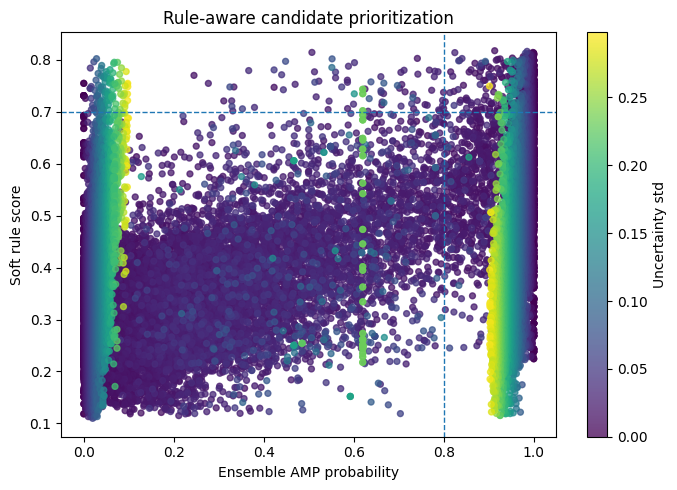

Saved: ../outputs_rule_prioritization/figures/probability_vs_rule_score_uncertainty.png


In [12]:
# ============================================================
# 12. Figure: probability vs rule support colored by uncertainty
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    ranked_df["probability_amp_ensemble"],
    ranked_df["soft_rule_score"],
    c=ranked_df["uncertainty_std"],
    s=18,
    alpha=0.75,
)
ax.set_xlabel("Ensemble AMP probability")
ax.set_ylabel("Soft rule score")
ax.set_title("Rule-aware candidate prioritization")
ax.axvline(HIGH_PROBABILITY_CUTOFF, linestyle="--", linewidth=1)
ax.axhline(HIGH_RULE_SCORE_CUTOFF, linestyle="--", linewidth=1)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Uncertainty std")
fig.tight_layout()

priority_scatter_path = FIGURE_DIR / "probability_vs_rule_score_uncertainty.png"
fig.savefig(priority_scatter_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", priority_scatter_path)

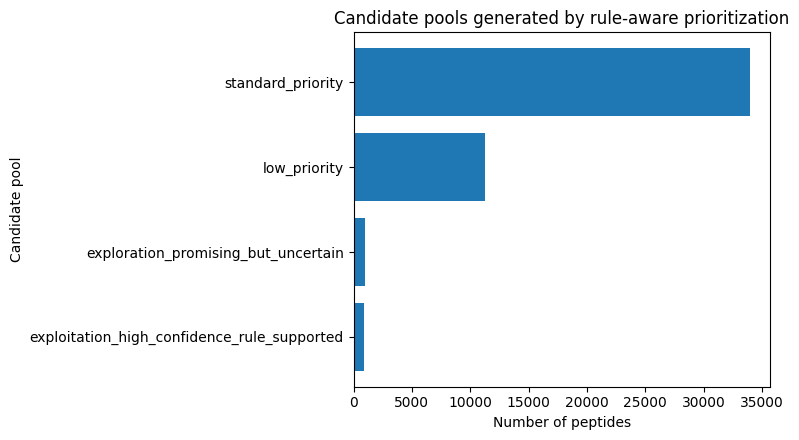

Saved: ../outputs_rule_prioritization/figures/candidate_pool_counts.png


In [13]:
# ============================================================
# 13. Figure: candidate pool counts
# ============================================================

pool_counts = ranked_df["candidate_pool"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(pool_counts.index, pool_counts.values)
ax.set_xlabel("Number of peptides")
ax.set_ylabel("Candidate pool")
ax.set_title("Candidate pools generated by rule-aware prioritization")
fig.tight_layout()

pool_counts_path = FIGURE_DIR / "candidate_pool_counts.png"
fig.savefig(pool_counts_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", pool_counts_path)

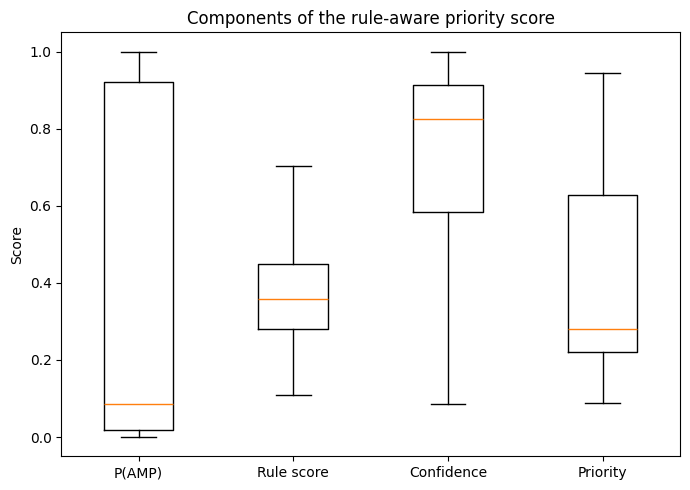

Saved: ../outputs_rule_prioritization/figures/priority_score_components_boxplot.png


In [14]:
# ============================================================
# 14. Figure: score component distributions
# ============================================================

score_components = [
    "probability_amp_ensemble",
    "soft_rule_score",
    "confidence_score",
    "rule_aware_priority_score",
]

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(
    [ranked_df[col].dropna().values for col in score_components],
    labels=["P(AMP)", "Rule score", "Confidence", "Priority"],
    showfliers=False,
)
ax.set_ylabel("Score")
ax.set_title("Components of the rule-aware priority score")
fig.tight_layout()

score_components_path = FIGURE_DIR / "priority_score_components_boxplot.png"
fig.savefig(score_components_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", score_components_path)

## 8. Export metadata

This metadata file records how the rule-aware prioritization score was generated, including score weights and candidate pool thresholds.

In [15]:
# ============================================================
# 15. Export metadata
# ============================================================

metadata = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "notebook": "05_rule_aware_prioritization",
    "training_metadata_path": str(TRAINING_METADATA_PATH),
    "best_model_selection_path": str(BEST_MODEL_SELECTION_PATH),
    "best_model_name": BEST_MODEL_NAME,
    "prediction_path": str(prediction_path),
    "rule_evidence_path": str(RULE_EVIDENCE_PATH),
    "candidate_rules_path": str(CANDIDATE_RULES_PATH),
    "n_candidates": int(len(ranked_df)),
    "n_rules": int(len(rulebook_df)),
    "top_n_rules": int(TOP_N_RULES),
    "score_formula": "0.55 * P(AMP) + 0.30 * soft_rule_score + 0.15 * confidence_score",
    "score_weights": {
        "probability_amp_ensemble": WEIGHT_PROBABILITY,
        "soft_rule_score": WEIGHT_RULE_SCORE,
        "confidence_score": WEIGHT_CONFIDENCE,
    },
    "uncertainty_normalization": "uncertainty_std divided by the 95th percentile and clipped to [0, 1]",
    "candidate_pool_thresholds": {
        "high_probability_cutoff": HIGH_PROBABILITY_CUTOFF,
        "low_probability_cutoff": LOW_PROBABILITY_CUTOFF,
        "high_rule_score_cutoff": HIGH_RULE_SCORE_CUTOFF,
        "low_rule_score_cutoff": LOW_RULE_SCORE_CUTOFF,
        "uncertainty_low_cutoff_q25": uncertainty_low_cutoff,
        "uncertainty_high_cutoff_q75": uncertainty_high_cutoff,
    },
    "outputs": {
        "rulebook": str(rulebook_path),
        "ranked_candidates": str(full_ranked_path),
        "top_candidates": str(top_candidates_path),
        "candidate_pool_summary": str(pool_summary_path),
        "rule_diagnostics": str(rule_diagnostics_path),
        "manuscript_rulebook": str(manuscript_rulebook_path),
        "manuscript_top_candidates": str(manuscript_top_candidates_path),
    },
}

metadata_path = OUTPUT_DIR / "rule_prioritization_metadata.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:", metadata_path)

Saved: ../outputs_rule_prioritization/rule_prioritization_metadata.json


In [16]:
# ============================================================
# 16. Final artefact list
# ============================================================

for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print(path)

../outputs_rule_prioritization/candidates/exploitation_high_confidence_rule_supported_candidates.csv
../outputs_rule_prioritization/candidates/exploration_promising_but_uncertain_candidates.csv
../outputs_rule_prioritization/candidates/low_priority_candidates.csv
../outputs_rule_prioritization/candidates/top_50_rule_aware_candidates.csv
../outputs_rule_prioritization/figures/candidate_pool_counts.png
../outputs_rule_prioritization/figures/priority_score_components_boxplot.png
../outputs_rule_prioritization/figures/probability_vs_rule_score_uncertainty.png
../outputs_rule_prioritization/rule_prioritization_metadata.json
../outputs_rule_prioritization/rules/amp_rulebook_from_shap_and_surrogate.csv
../outputs_rule_prioritization/tables/all_candidates_rule_aware_ranked.csv
../outputs_rule_prioritization/tables/candidate_pool_summary.csv
../outputs_rule_prioritization/tables/manuscript_ready_rulebook.csv
../outputs_rule_prioritization/tables/manuscript_ready_top_20_candidates.csv
../outputs

# Notes for Notebook 06

The next notebook can use:

- `outputs_rule_prioritization/rules/amp_rulebook_from_shap_and_surrogate.csv`
- `outputs_rule_prioritization/tables/all_candidates_rule_aware_ranked.csv`
- `outputs_rule_prioritization/candidates/top_50_rule_aware_candidates.csv`
- `outputs_rule_prioritization/candidates/exploration_promising_but_uncertain_candidates.csv`

These files can support an external candidate screening workflow using UniProt-derived sequences and an illustrative in silico design–test–learn cycle.